In [20]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import re
from sklearn.preprocessing import StandardScaler


con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT value, delimit_value, delimit_value2,analysis, protein_value, manual_classification as label 
                 FROM protein_data 
                 WHERE manual_classification IS NOT NULL 
                 AND value IS NOT NULL
                 AND delimit_value IS NOT NULL
                 AND delimit_value2 IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()

con.close()


def extract_relevant_values(analysis_list, value_list, relevant):
    # Skapa dict från analysis -> value för denna rad
    mapping = dict(zip(analysis_list, value_list))
    
    # Plocka ut relevanta värden i fast ordning
    return [mapping.get(code, np.nan) for code in relevant]

def extract_fractions(delimit_list):
    fractions = []
    for item in delimit_list:
        match = re.search(r'(\d+\.?\d*)\s*%', str(item))
        if match:
            fractions.append(float(match.group(1)))
    return fractions

def clean_value(val):
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan

def clean_protein_values(val_list):
    return [clean_value(v) for v in val_list]

#value
df = df[ df['value'].apply(len) == 301 ] #vaska de rader där value inte har rätt längd (typ bara en korrupt rad)
df['value'] = df['value'].apply(lambda x: x[:300])

#delimit_value
df['delimit_value'] = df['delimit_value'].apply(extract_fractions)
df = df[ df['delimit_value'].apply(len) == 6]

#delimit_value2
df = df[ df['delimit_value2'].apply(len) == 15]

#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)
df['protein_value'] = df['protein_value'].apply(clean_protein_values)

X_curve     = np.array(df['value'].tolist(),         dtype=np.float32)  # (n, 300)
X_fractions = np.array(df['delimit_value'].tolist(),  dtype=np.float32)  # (n, 6)
X_delimit2  = np.array(df['delimit_value2'].tolist(), dtype=np.float32)  # (n, 15)
#X_protein   = np.array(df['protein_value'].tolist(),  dtype=np.float32)  # (n, 8)

X = np.concatenate([X_curve, X_fractions, X_delimit2], axis=1)  # (n, 329)
y = np.array(df['label'].values, dtype=np.int64)


print(X.shape) 
print(y.shape)  

# Kolla att det inte finns NaN eller inf
print(f"NaN: {np.isnan(X).sum()}")
print(f"Inf: {np.isinf(X).sum()}")

# Kolla klassbalansen
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"Label {val}: {count} ({count/len(y)*100:.1f}%)")



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(134299, 321)
(134299,)
NaN: 0
Inf: 0
Label 0: 106177 (79.1%)
Label 1: 28122 (20.9%)


In [21]:

# Först: låt 15% vara test-set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Sedan: dela resten i träning/validering (0.1765 ≈ 15% av totalen)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

# Normalisera bara de extra features, inte kurvan
scaler = StandardScaler()
X_train[:, 300:] = scaler.fit_transform(X_train[:, 300:])
X_val[:, 300:]   = scaler.transform(X_val[:, 300:])
X_test[:, 300:]  = scaler.transform(X_test[:, 300:])

X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.long)

X_val = torch.tensor(X_val,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.long)

X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.long)


print(f"Träning:    {len(X_train):>6} ({len(X_train)/len(y):.0%})")
print(f"Validering: {len(X_val):>6} ({len(X_val)/len(y):.0%})")
print(f"Test:       {len(X_test):>6} ({len(X_test)/len(y):.0%})")

print(torch.isnan(X_train).sum())
print(torch.isinf(X_train).sum())

Träning:     94005 (70%)
Validering:  20149 (15%)
Test:        20145 (15%)
tensor(0)
tensor(0)


In [22]:
batch_sz = 256

# DataLoaders
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_sz, shuffle=True)
val_dataloader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_sz)
test_dataloader   = DataLoader(TensorDataset(X_test,   y_test),   batch_size=batch_sz)

for X, y in val_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    break

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(321, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits
    
def train(train_dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

def validate(val_dataloader, model, loss_fn):
    size = len(val_dataloader.dataset)
    num_batches = len(val_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)

def test(test_dataloader, model, loss_fn):
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    return (100*correct,test_loss)


model = NeuralNetwork().to(device)
pos_weight = torch.tensor([1.0, 3.0]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Antal parametrar: {total_params:,}")

Shape of X: torch.Size([256, 321])
Shape of y: torch.Size([256])
Using mps device
NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=321, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=2, bias=True)
  )
)
Antal parametrar: 255,298


In [23]:
## KÖR DETTA BLOCKET FÖR ATT TRÄNA! Annars kör nästa block och läs in vikterna!
epochs = 50
accuracies = []
validation_losses = []
for t in range(epochs):
    train(train_dataloader, model, loss_fn, optimizer)
    (accuracy,avg_loss) = validate(val_dataloader, model, loss_fn)
    scheduler.step()
    print(f"Epooch {t}, accuracy: {accuracy}, Avg loss: {avg_loss}")
    accuracies.append(accuracy)
    validation_losses.append(avg_loss)
print("Done!")

torch.save(model.state_dict(), "advanced_model.pth")
print("Saved PyTorch Model State to advanced_model.pth")


Epooch 0, accuracy: 92.78376098069383, Avg loss: 0.32483294757106634
Epooch 1, accuracy: 92.05419623802669, Avg loss: 0.2922425462475306
Epooch 2, accuracy: 81.4581368802422, Avg loss: 0.37019150732438777
Epooch 3, accuracy: 90.47595414164475, Avg loss: 0.2734811619112763
Epooch 4, accuracy: 93.61258623256738, Avg loss: 0.32245119104656994
Epooch 5, accuracy: 92.19316095091568, Avg loss: 0.2572928237009652
Epooch 6, accuracy: 95.46875775472728, Avg loss: 0.23122721787872194
Epooch 7, accuracy: 86.96213211573776, Avg loss: 0.3414776853368252
Epooch 8, accuracy: 95.50846195840985, Avg loss: 0.17598360211034364
Epooch 9, accuracy: 95.45386867834632, Avg loss: 0.19495515685669984
Epooch 10, accuracy: 95.87572584247357, Avg loss: 0.17868234170011327
Epooch 11, accuracy: 94.73919301206016, Avg loss: 0.193866829234588
Epooch 12, accuracy: 96.19335947193409, Avg loss: 0.17044418380607532
Epooch 13, accuracy: 95.34964514367958, Avg loss: 0.1745902171617822
Epooch 14, accuracy: 96.05439475904511

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load("advanced_model.pth", weights_only=True))

# Samla alla prediktioner
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Hitta FN
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]
print(f"Antal FN: {len(fn_idx)}")
# Rapport
print(classification_report(all_labels, all_preds, target_names=['Negativ', 'Positiv']))

# Konfusionsmatris
print(confusion_matrix(all_labels, all_preds))

(test_accuracy, test_loss) = test(test_dataloader,model,loss_fn)
print(f"Resultat på testdatan: accuracy: {test_accuracy}, Avg loss: {test_loss}")


Antal FN: 365
              precision    recall  f1-score   support

     Negativ       0.98      0.96      0.97     15927
     Positiv       0.86      0.91      0.88      4218

    accuracy                           0.95     20145
   macro avg       0.92      0.94      0.93     20145
weighted avg       0.95      0.95      0.95     20145

[[15284   643]
 [  365  3853]]
Resultat på testdatan: accuracy: 94.99627699180938, Avg loss: 0.18378298710795898


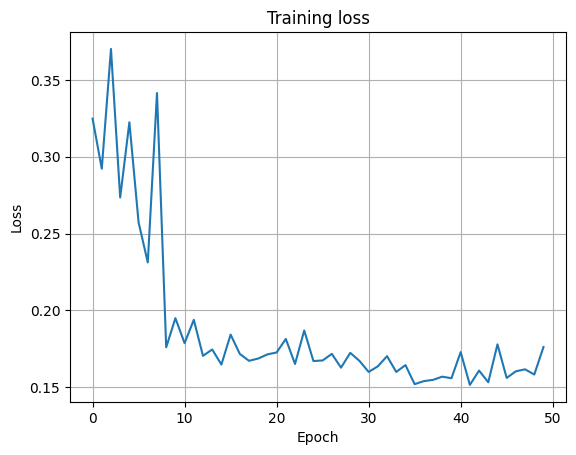

In [30]:
# Analys av hur träningen gick
import matplotlib.pyplot as plt

plt.plot(validation_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)
plt.show()

In [31]:
# Hitta FN - patienter med M-komponent som modellen missar
from sklearn.metrics import confusion_matrix
# samla prediktioner...
fn_idx = np.where((all_labels == 1) & (all_preds == 0))[0]
print(f"Antal FN: {len(fn_idx)}")

# Kolla vad dessa kurvor har gemensamt
X_fn = X_val[fn_idx]
print(f"Medelvärde FN kurvor: {X_fn.mean(axis=0)}")

Antal FN: 365
Medelvärde FN kurvor: tensor([ 1.9616e+00,  1.9342e+00,  2.0027e+00,  2.1397e+00,  2.1671e+00,
         2.2740e+00,  2.3890e+00,  2.5425e+00,  2.7178e+00,  2.9123e+00,
         3.1014e+00,  3.3014e+00,  3.5644e+00,  3.6575e+00,  3.9699e+00,
         4.2849e+00,  4.6767e+00,  5.1562e+00,  5.6548e+00,  6.1890e+00,
         6.7644e+00,  7.1342e+00,  7.6712e+00,  8.1973e+00,  8.7479e+00,
         9.2740e+00,  9.8822e+00,  1.0510e+01,  1.1392e+01,  1.2241e+01,
         1.3641e+01,  1.5252e+01,  1.7178e+01,  1.9696e+01,  2.2455e+01,
         2.5178e+01,  2.7438e+01,  2.8638e+01,  2.8575e+01,  2.6921e+01,
         2.4156e+01,  2.0608e+01,  1.7334e+01,  1.4740e+01,  1.2921e+01,
         1.2038e+01,  1.1696e+01,  1.1805e+01,  1.2293e+01,  1.3140e+01,
         1.4170e+01,  1.5510e+01,  1.7022e+01,  1.8677e+01,  2.0490e+01,
         2.2721e+01,  2.5252e+01,  2.8375e+01,  3.2112e+01,  3.6915e+01,
         4.3008e+01,  5.0323e+01,  5.8964e+01,  6.9288e+01,  8.1584e+01,
         9.5986